In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.layers import (Conv2D, TimeDistributed, MaxPooling2D,
                                     MaxPooling3D, AveragePooling2D, Conv2DTranspose, UpSampling2D,
                                     Dense, Flatten, Reshape,Dropout)
from hopf_blurred import *
#from pulse2percept.stimuli import GratingStimulus
import scipy.io

import numpy as np
import os

d:\pYthon_Directory\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\pYthon_Directory\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
import scipy.io
data5=np.load('E:/lab work 2026/appril/fmri/main_data/images.npy')

EEG_data=data5 # 4 channels EEG TRAINING Data

print(EEG_data.shape,"raw_data")
import numpy as np

fmri = np.transpose(EEG_data, (3, 2, 0, 1))
fmri = np.expand_dims(fmri, axis=-1)
print(fmri.shape)
import tensorflow as tf

# data shape = (756, 64, 40, 64, 1)

fmri = tf.image.resize(
    fmri.reshape(-1, 40, 64, 1),
    size=(40, 40)
)

fmri = tf.reshape(
    fmri,
    (756, 64, 40, 40, 1)
)

print(fmri.shape)
input_dim=40
seq_len=64
from tensorflow.keras import layers, Model

def feat_pool_dim_calc(inp_dim, k_dim, pool_dim=2):
  f_d = (inp_dim-k_dim) + 1
  p_d = (f_d-pool_dim)//pool_dim + 1
  return f_d, p_d

k1_d = 5
n_f1 = 5
f1_d, p1_d = feat_pool_dim_calc(input_dim, k1_d)

k2_d = 5
n_f2 = 5
#f2_d, p2_d = feat_pool_dim_calc(f1_d//2, k2_d)
f2_d, p2_d = feat_pool_dim_calc(f1_d, k2_d)

k3_d = 5
n_f3 = 10
#f3_d, p3_d = feat_pool_dim_calc(f2_d//2, k3_d)
f3_d, p3_d = feat_pool_dim_calc(f2_d, k3_d)

k4_d = 5
n_f4 = 10
f4_d, p4_d = feat_pool_dim_calc(f3_d, k4_d)

f1_d, f2_d, f3_d, f4_d



(40, 64, 64, 756) raw_data
(756, 64, 40, 64, 1)
(756, 64, 40, 40, 1)


(36, 32, 28, 24)

In [3]:
from tensorflow.keras.layers import (
    Conv2D,
    Conv2DTranspose,
    TimeDistributed,
    Dense,
    Flatten,
    Reshape
)

class HopfAutoencoder(Model):

    def __init__(self):
        super().__init__()

        # Encoder
        self.conv_r1 = TimeDistributed(
            Conv2D(n_f1, (k1_d, k1_d), activation='relu', padding='valid')
        )

        self.conv_i1 = TimeDistributed(
            Conv2D(n_f1, (k1_d, k1_d), activation='relu', padding='valid')
        )

        self.h1 = Hopf(f1_d, n_f1, seq_len,
                       min_omega=0.1, max_omega=3.1)

        self.conv_r2 = TimeDistributed(
            Conv2D(n_f2, (k2_d, k2_d), activation='relu', padding='valid')
        )

        self.conv_i2 = TimeDistributed(
            Conv2D(n_f2, (k2_d, k2_d), activation='relu', padding='valid')
        )

        self.h2 = Hopf(f2_d, n_f2, seq_len,
                       min_omega=0.1, max_omega=3.1)

        # ---------- Dense Bottleneck ----------

        self.flatten = TimeDistributed(Flatten())

        self.td_dense1 = TimeDistributed(Dense(512, activation='relu'))
        self.td_dense2 = TimeDistributed(Dense(256, activation='relu'))
        

        # Determine latent spatial size
        latent_h = f2_d
        latent_w = f2_d
        latent_c = 2 * n_f2   # z2_r + z2_i concatenated

        self.reconstruct_dense = TimeDistributed(
            Dense(latent_h * latent_w * latent_c,
                  activation='relu')
        )

        self.reshape_layer = TimeDistributed(
            Reshape((latent_h, latent_w, latent_c))
        )

        # Decoder
        self.dec1 = TimeDistributed(
            Conv2DTranspose(
                filters=n_f1,
                kernel_size=(5, 5),
                padding='valid',
                activation='relu'
            )
        )

        self.dec2 = TimeDistributed(
            Conv2DTranspose(
                filters=n_f1,
                kernel_size=(5, 5),
                padding='valid',
                activation='relu'
            )
        )

        self.dec3 = TimeDistributed(
            Conv2D(
                filters=n_f1,
                kernel_size=(3, 3),
                padding='same',
                activation='relu'
            )
        )

        self.dec4 = TimeDistributed(
            Conv2D(
                filters=1,
                kernel_size=(1, 1),
                padding='same',
                activation='sigmoid'
            )
        )

    def call(self, inputs):

        # Encoder
        cor1 = self.conv_r1(inputs)
        coi1 = self.conv_i1(inputs)

        z1_r, z1_i = self.h1(cor1, coi1)

        cor2 = self.conv_r2(z1_r)
        coi2 = self.conv_i2(z1_i)

        z2_r, z2_i = self.h2(cor2, coi2)

        latent = tf.concat([z2_r, z2_i], axis=-1)

        # Dense bottleneck
        x = self.flatten(latent)

        x = self.td_dense1(x)
        x = self.td_dense2(x)
        
        x = self.reconstruct_dense(x)
        x = self.reshape_layer(x)

        # Decoder
        x = self.dec1(x)
        x = self.dec2(x)
        x = self.dec3(x)

        reconstructed = self.dec4(x)

        return reconstructed

In [4]:

model = HopfAutoencoder()

model.build(input_shape=(2, 64, 40, 40, 1))
model.summary()

Model: "hopf_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  multiple                 130       
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  multiple                 130       
 tributed)                                                       
                                                                 
 hopf (Hopf)                 multiple                  0         
                                                                 
 time_distributed_2 (TimeDis  multiple                 630       
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  multiple                 630       
 tributed)                                        

In [5]:
x_train = fmri[:600]
x_test  = fmri[600:]
print(x_train.shape, x_test.shape)

(600, 64, 40, 40, 1) (156, 64, 40, 40, 1)


In [6]:
model.compile(optimizer='adam',loss='mse')
history = model.fit(
    x_train,
    x_train,
    shuffle=True,
    epochs=100,
    batch_size=10,
    validation_split=0.2
)


Epoch 1/100
48/48 [==============================] - 149s 3s/step - loss: 0.0203 - val_loss: 0.0050
Epoch 2/100
48/48 [==============================] - 139s 3s/step - loss: 0.0045 - val_loss: 0.0039
Epoch 3/100
48/48 [==============================] - 167s 3s/step - loss: 0.0036 - val_loss: 0.0033
Epoch 4/100
48/48 [==============================] - 177s 4s/step - loss: 0.0029 - val_loss: 0.0028
Epoch 5/100
48/48 [==============================] - 189s 4s/step - loss: 0.0025 - val_loss: 0.0023
Epoch 6/100
48/48 [==============================] - 164s 3s/step - loss: 0.0021 - val_loss: 0.0020
Epoch 7/100
48/48 [==============================] - 162s 3s/step - loss: 0.0018 - val_loss: 0.0017
Epoch 8/100
48/48 [==============================] - 162s 3s/step - loss: 0.0016 - val_loss: 0.0015
Epoch 9/100
48/48 [==============================] - 161s 3s/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/100
48/48 [==============================] - 160s 3s/step - loss: 0.0012 - val_loss: 0.0011

In [7]:
x_test_pred = model.predict(x_test, batch_size=1)

156/156 [==============================] - 16s 94ms/step


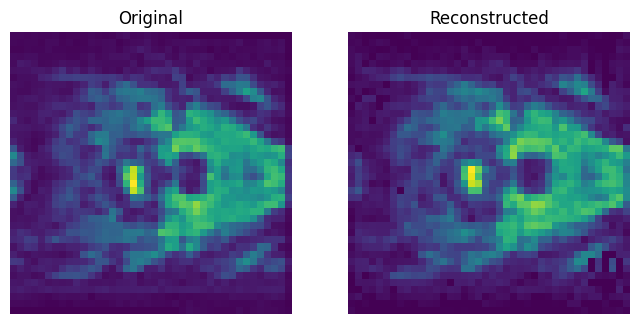

In [8]:

import matplotlib.pyplot as plt

sample_idx = 49
frame_idx = 6

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(x_test[sample_idx, frame_idx, :, :, 0], cmap='viridis')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(x_test_pred[sample_idx, frame_idx, :, :, 0], cmap='viridis')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

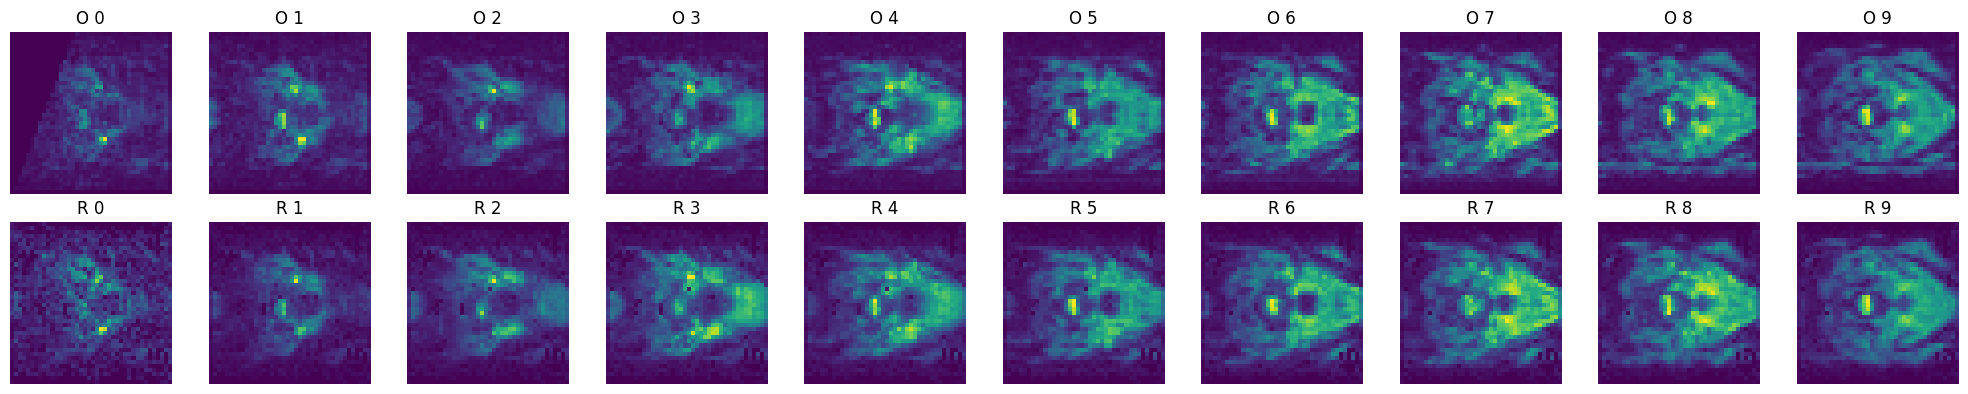

In [9]:
import matplotlib.pyplot as plt

sample_idx = 20
num_frames = 10

plt.figure(figsize=(20, 4))

for i in range(num_frames):
    # Original
    plt.subplot(2, num_frames, i + 1)
    plt.imshow(x_test[sample_idx, i, :, :, 0], cmap='viridis')
    plt.title(f"O {i}")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, num_frames, num_frames + i + 1)
    plt.imshow(x_test_pred[sample_idx, i, :, :, 0], cmap='viridis')
    plt.title(f"R {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
x_test_pred.shape

(156, 64, 40, 40, 1)

In [11]:
x_test.shape

TensorShape([156, 64, 40, 40, 1])

In [15]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

x_true = x_test.numpy()
x_pred = x_test_pred

ssim_scores = []

for n in range(x_true.shape[0]):
    for t in range(x_true.shape[1]):

        gt = x_true[n, t, :, :, 0]
        pred = x_pred[n, t, :, :, 0]

        score = ssim(
            gt,
            pred,
            data_range=1.0   # if normalized to [0,1]
        )

        ssim_scores.append(score)

print("Mean SSIM =", np.mean(ssim_scores))

Mean SSIM = 0.9483470203525973


In [16]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

x_true = x_test.numpy()
x_pred = x_test_pred

best_ssim = -1
best_sample = None
best_frame = None

for n in range(x_true.shape[0]):
    for t in range(x_true.shape[1]):

        gt = x_true[n, t, :, :, 0]
        pred = x_pred[n, t, :, :, 0]

        score = ssim(
            gt,
            pred,
            data_range=1.0
        )

        if score > best_ssim:
            best_ssim = score
            best_sample = n
            best_frame = t

print("Best SSIM :", best_ssim)
print("Sample    :", best_sample)
print("Frame     :", best_frame)

Best SSIM : 0.9833031174648073
Sample    : 75
Frame     : 61


In [ ]:
mean_ssim = np.mean(ssim_scores)

delta_ssim = abs(1.0 - mean_ssim)

print("Mean SSIM =", mean_ssim)
print("|ΔSSIM| =", delta_ssim)

Mean SSIM = 0.9483470203525973
|ΔSSIM| = 0.051652979647402675


In [18]:
delta_ssim_best = abs(1.0 - best_ssim)

print("Best SSIM =", best_ssim)
print("|ΔSSIM| =", delta_ssim_best)

Best SSIM = 0.9833031174648073
|ΔSSIM| = 0.016696882535192747


OVERALL RESULTS
Mean SSIM : 0.948347
Std SSIM  : 0.021219
Mean MAE  : 0.010725
Std MAE   : 0.004601


BEST FRAME
Best Sample : 75
Best Frame  : 61
Best SSIM   : 0.983303
|ΔSSIM|     : 0.016697
Best MAE    : 0.002395


WORST FRAME
Worst Sample : 31
Worst Frame  : 0
Worst SSIM   : 0.765255
Worst MAE    : 0.004929


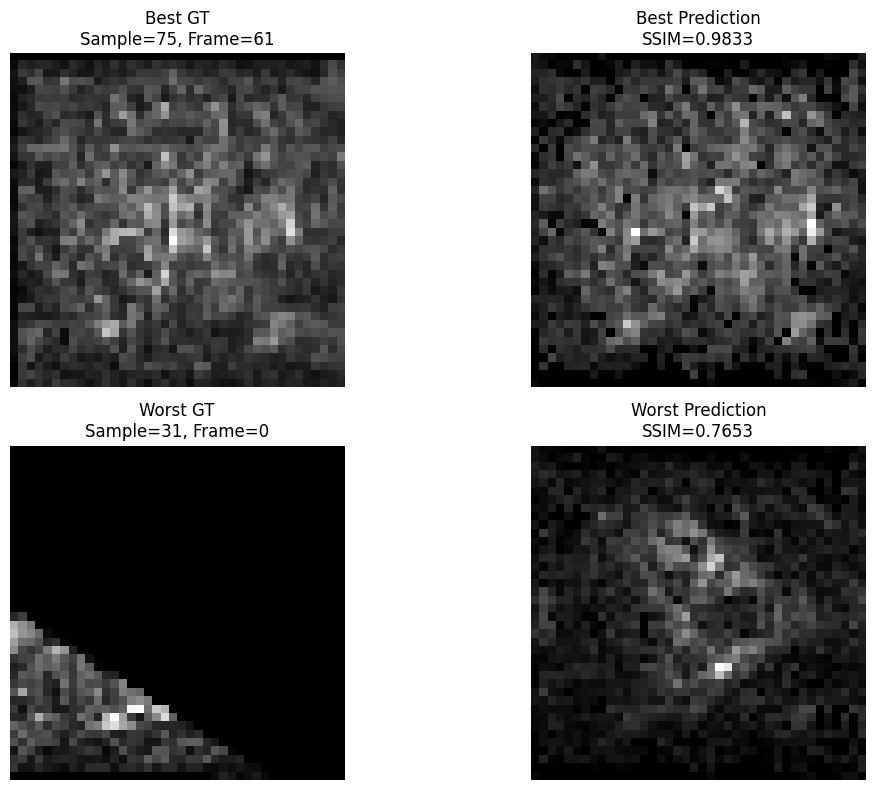

In [19]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

# Convert TensorFlow tensor to NumPy if needed
x_true = x_test.numpy() if hasattr(x_test, "numpy") else x_test
x_pred = x_test_pred.numpy() if hasattr(x_test_pred, "numpy") else x_test_pred

# Lists to store metrics
ssim_scores = []
mae_scores = []

# Track best and worst SSIM frames
best_ssim = -1
worst_ssim = 2

best_sample = None
best_frame = None

worst_sample = None
worst_frame = None

# Loop through all samples and frames
for n in range(x_true.shape[0]):
    for t in range(x_true.shape[1]):

        gt = x_true[n, t, :, :, 0]
        pred = x_pred[n, t, :, :, 0]

        # SSIM
        score = ssim(
            gt,
            pred,
            data_range=1.0      # change if your data is not normalized
        )

        ssim_scores.append(score)

        # MAE
        mae = np.mean(np.abs(gt - pred))
        mae_scores.append(mae)

        # Best frame
        if score > best_ssim:
            best_ssim = score
            best_sample = n
            best_frame = t
            best_mae = mae

        # Worst frame
        if score < worst_ssim:
            worst_ssim = score
            worst_sample = n
            worst_frame = t
            worst_mae = mae

# Overall metrics
mean_ssim = np.mean(ssim_scores)
std_ssim = np.std(ssim_scores)

mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

# Delta SSIM from perfect reconstruction
delta_ssim_best = abs(1.0 - best_ssim)

print("="*50)
print("OVERALL RESULTS")
print("="*50)

print(f"Mean SSIM : {mean_ssim:.6f}")
print(f"Std SSIM  : {std_ssim:.6f}")

print(f"Mean MAE  : {mean_mae:.6f}")
print(f"Std MAE   : {std_mae:.6f}")

print("\n")

print("="*50)
print("BEST FRAME")
print("="*50)

print(f"Best Sample : {best_sample}")
print(f"Best Frame  : {best_frame}")

print(f"Best SSIM   : {best_ssim:.6f}")
print(f"|ΔSSIM|     : {delta_ssim_best:.6f}")
print(f"Best MAE    : {best_mae:.6f}")

print("\n")

print("="*50)
print("WORST FRAME")
print("="*50)

print(f"Worst Sample : {worst_sample}")
print(f"Worst Frame  : {worst_frame}")

print(f"Worst SSIM   : {worst_ssim:.6f}")
print(f"Worst MAE    : {worst_mae:.6f}")

# Retrieve images for visualization
best_gt = x_true[best_sample, best_frame, :, :, 0]
best_pred = x_pred[best_sample, best_frame, :, :, 0]

worst_gt = x_true[worst_sample, worst_frame, :, :, 0]
worst_pred = x_pred[worst_sample, worst_frame, :, :, 0]

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(best_gt, cmap='gray')
plt.title(f'Best GT\nSample={best_sample}, Frame={best_frame}')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(best_pred, cmap='gray')
plt.title(f'Best Prediction\nSSIM={best_ssim:.4f}')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(worst_gt, cmap='gray')
plt.title(f'Worst GT\nSample={worst_sample}, Frame={worst_frame}')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(worst_pred, cmap='gray')
plt.title(f'Worst Prediction\nSSIM={worst_ssim:.4f}')
plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from sklearn.metrics import r2_score
from skimage.metrics import structural_similarity as ssim

# Convert tensors to numpy if needed
x_true = x_test.numpy() if hasattr(x_test, "numpy") else x_test
x_pred = x_test_pred.numpy() if hasattr(x_test_pred, "numpy") else x_test_pred

print("x_true shape :", x_true.shape)
print("x_pred shape :", x_pred.shape)

# =====================================================
# 1. OVERALL R²
# =====================================================

overall_r2 = r2_score(
    x_true.flatten(),
    x_pred.flatten()
)

print("\n" + "="*50)
print("OVERALL R²")
print("="*50)
print(f"Overall R² = {overall_r2:.6f}")

# =====================================================
# 2. R² FOR EACH fMRI SEQUENCE
# =====================================================

r2_per_sequence = []

for n in range(x_true.shape[0]):

    r2_n = r2_score(
        x_true[n].flatten(),
        x_pred[n].flatten()
    )

    r2_per_sequence.append(r2_n)

r2_per_sequence = np.array(r2_per_sequence)

print("\n" + "="*50)
print("SEQUENCE-WISE R²")
print("="*50)

print(f"Mean R² = {np.mean(r2_per_sequence):.6f}")
print(f"Std  R² = {np.std(r2_per_sequence):.6f}")

# =====================================================
# 3. BEST AND WORST R² SEQUENCES
# =====================================================

best_seq_idx = np.argmax(r2_per_sequence)
worst_seq_idx = np.argmin(r2_per_sequence)

best_seq_r2 = r2_per_sequence[best_seq_idx]
worst_seq_r2 = r2_per_sequence[worst_seq_idx]

print("\n" + "="*50)
print("BEST / WORST SEQUENCES")
print("="*50)

print(f"Best Sequence Index  : {best_seq_idx}")
print(f"Best Sequence R²     : {best_seq_r2:.6f}")

print(f"Worst Sequence Index : {worst_seq_idx}")
print(f"Worst Sequence R²    : {worst_seq_r2:.6f}")

# =====================================================
# 4. FIND BEST SSIM FRAME
# =====================================================

best_ssim = -1
best_sample = None
best_frame = None

for n in range(x_true.shape[0]):
    for t in range(x_true.shape[1]):

        gt = x_true[n, t, :, :, 0]
        pred = x_pred[n, t, :, :, 0]

        score = ssim(
            gt,
            pred,
            data_range=1.0
        )

        if score > best_ssim:
            best_ssim = score
            best_sample = n
            best_frame = t

# =====================================================
# 5. R² OF BEST SSIM FRAME
# =====================================================

best_gt = x_true[best_sample, best_frame, :, :, 0]
best_pred = x_pred[best_sample, best_frame, :, :, 0]

best_frame_r2 = r2_score(
    best_gt.flatten(),
    best_pred.flatten()
)

print("\n" + "="*50)
print("BEST SSIM FRAME")
print("="*50)

print(f"Sample Index : {best_sample}")
print(f"Frame Index  : {best_frame}")
print(f"Best SSIM    : {best_ssim:.6f}")
print(f"Frame R²     : {best_frame_r2:.6f}")

# =====================================================
# 6. ΔR² FROM PERFECT RECONSTRUCTION
# =====================================================

delta_r2 = abs(1.0 - overall_r2)

print("\n" + "="*50)
print("ΔR²")
print("="*50)

print(f"|ΔR²| = {delta_r2:.6f}")

x_true shape : (156, 64, 40, 40, 1)
x_pred shape : (156, 64, 40, 40, 1)

OVERALL R²
Overall R² = 0.992703

SEQUENCE-WISE R²
Mean R² = 0.992704
Std  R² = 0.000751

BEST / WORST SEQUENCES
Best Sequence Index  : 56
Best Sequence R²     : 0.993474
Worst Sequence Index : 47
Worst Sequence R²    : 0.989803

BEST SSIM FRAME
Sample Index : 75
Frame Index  : 61
Best SSIM    : 0.983303
Frame R²     : 0.297352

ΔR²
|ΔR²| = 0.007297


In [23]:
model.summary()

Model: "hopf_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  multiple                 130       
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  multiple                 130       
 tributed)                                                       
                                                                 
 hopf (Hopf)                 multiple                  0         
                                                                 
 time_distributed_2 (TimeDis  multiple                 630       
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  multiple                 630       
 tributed)                                        

In [24]:
print(type(model))
print(model)

for layer in model.layers:
    print(layer.name, layer.output_shape if hasattr(layer, 'output_shape') else "No output shape")

<class '__main__.HopfAutoencoder'>
time_distributed No output shape
time_distributed_1 No output shape
hopf No output shape
time_distributed_2 No output shape
time_distributed_3 No output shape
hopf_1 No output shape
time_distributed_4 No output shape
time_distributed_5 No output shape
time_distributed_6 No output shape
time_distributed_7 No output shape
time_distributed_8 No output shape
time_distributed_9 No output shape
time_distributed_10 No output shape
time_distributed_11 No output shape
time_distributed_12 No output shape


In [25]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 time_distributed <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
1 time_distributed_1 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
2 hopf <class 'hopf_blurred.Hopf'>
3 time_distributed_2 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
4 time_distributed_3 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
5 hopf_1 <class 'hopf_blurred.Hopf'>
6 time_distributed_4 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
7 time_distributed_5 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
8 time_distributed_6 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
9 time_distributed_7 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
10 time_distributed_8 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
11 time_distributed_9 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
12 time_distributed_10 <class 'keras.layers.rnn.time_distributed.TimeDistributed'>
13 time_distributed_11 <class 'kera

In [28]:
cor1 = model.conv_r1(x_test)
coi1 = model.conv_i1(x_test)

z1_r, z1_i = model.h1(cor1, coi1)

cor2 = model.conv_r2(z1_r)
coi2 = model.conv_i2(z1_i)

z2_r, z2_i = model.h2(cor2, coi2)

latent = tf.concat([z2_r, z2_i], axis=-1)

x = model.flatten(latent)

x = model.td_dense1(x)

latent_features = model.td_dense2(x)

print(latent_features.shape)

(156, 64, 256)


In [29]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [30]:
latent_np = latent_features.numpy()

latent_flat = latent_np.reshape(-1, latent_np.shape[-1])

print(latent_flat.shape)

(9984, 256)


In [31]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    random_state=42
)

embedding = tsne.fit_transform(latent_flat)

print(embedding.shape)


(9984, 2)


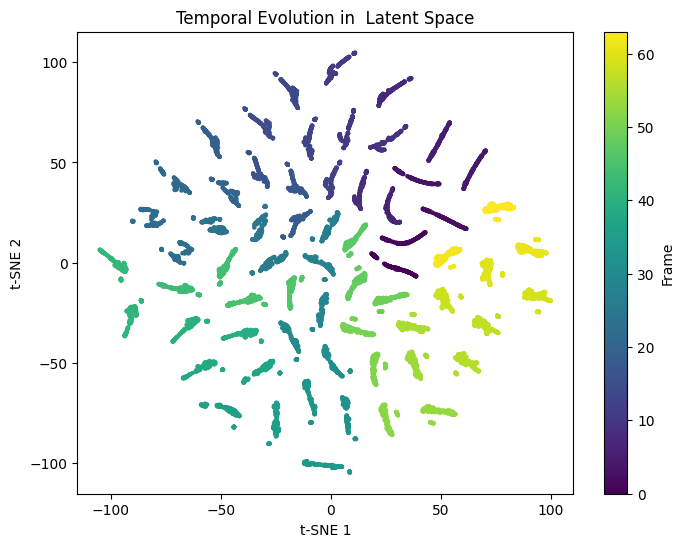

In [33]:
frame_ids = np.tile(np.arange(64), 156)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=frame_ids,
    s=5
)

plt.colorbar(sc,label="Frame")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.title("Temporal Evolution in  Latent Space")

plt.show()

In [34]:
amp2 = tf.sqrt(z2_r**2 + z2_i**2)
print(amp2.shape)

(156, 64, 32, 32, 5)


In [36]:
amp_mean = tf.reduce_mean(amp2, axis=[2,3])
print(amp_mean.shape)

(156, 64, 5)


(-1.3946720838546753,
 1.3242825746536255,
 -1.3050564229488373,
 1.5918717086315155)

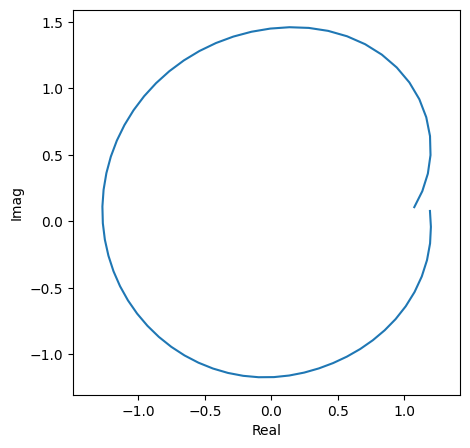

In [56]:
sample = 0
osc = 0
h = 16
w = 16

plt.figure(figsize=(5,5))
plt.plot(
    z2_r[sample,:,h,w,osc],
    z2_i[sample,:,h,w,osc]
)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.axis('equal')

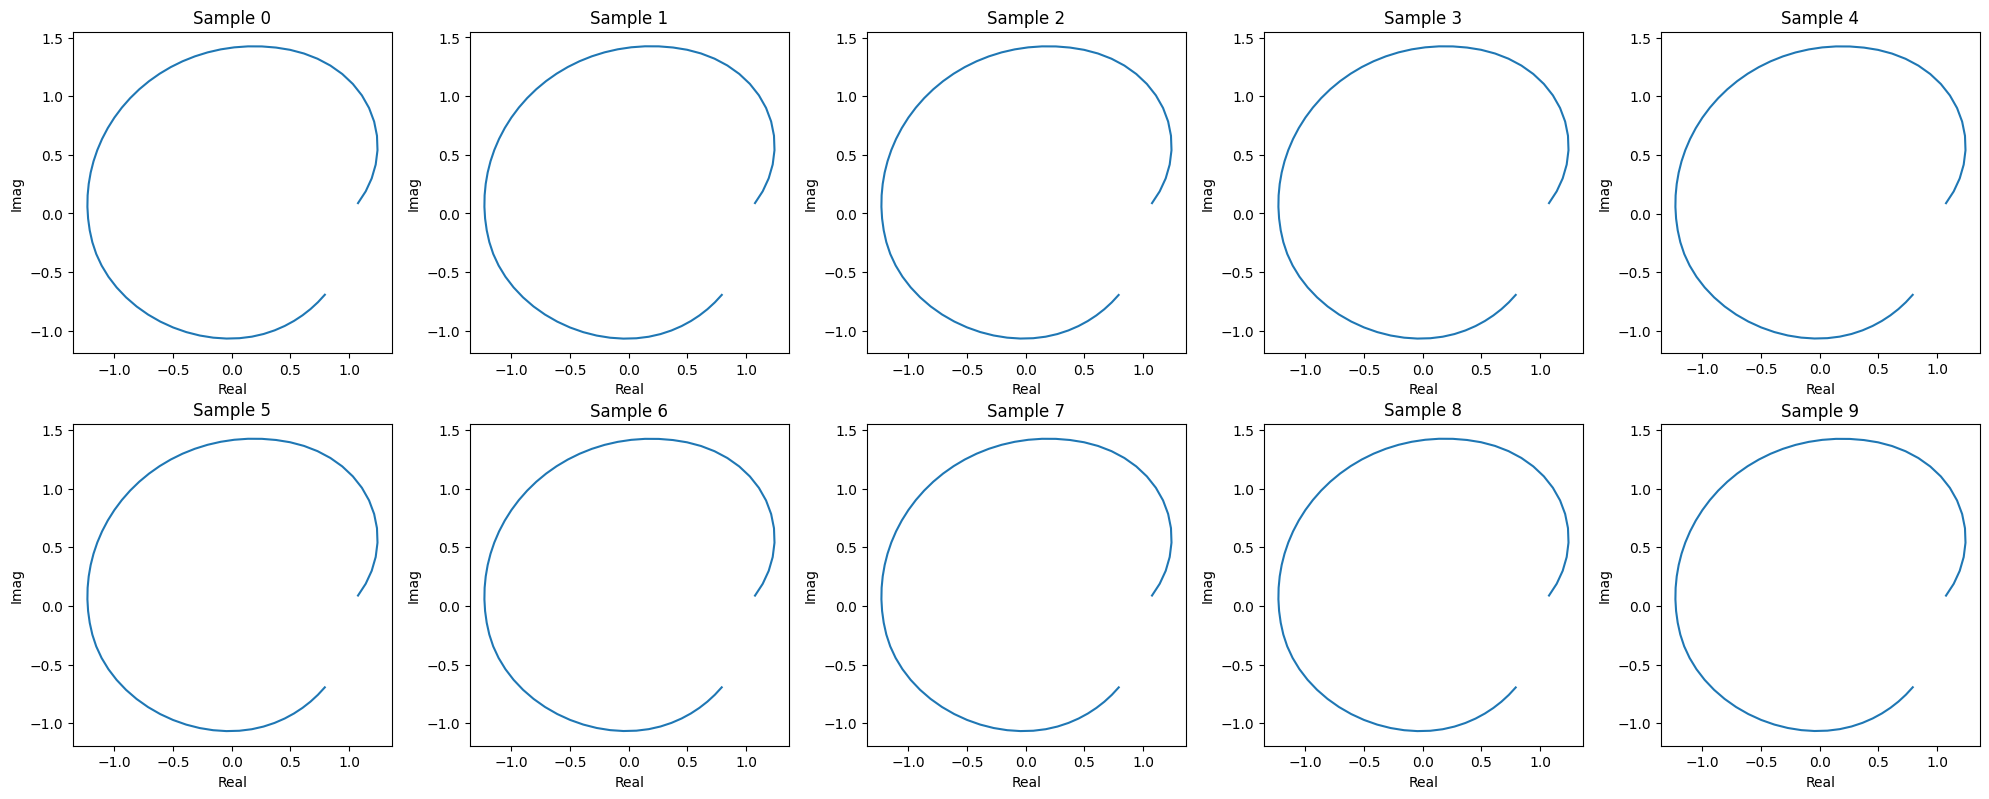

In [62]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, ax in enumerate(axes.flat):
    ax.plot(
        z2_r[i, :, 0, 0, 0],
        z2_i[i, :, 0, 0, 0]
    )
    ax.set_aspect('equal')
    ax.set_title(f'Sample {i}')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imag')

plt.tight_layout()
plt.show()

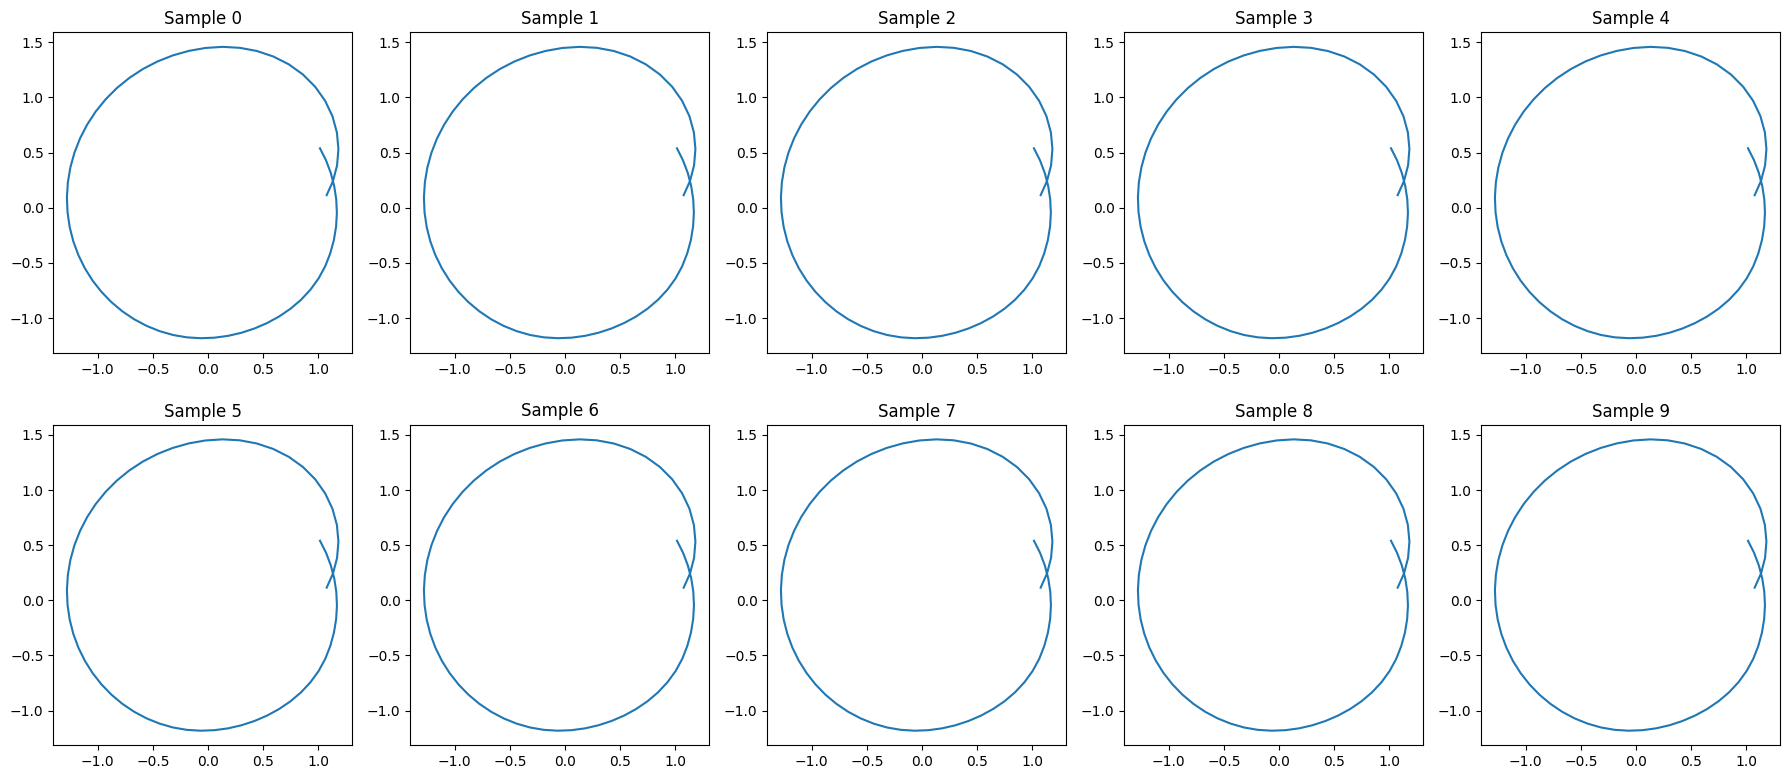

In [66]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(18,8)
)

for s, ax in enumerate(axes.flat):

    x = z2_r[s,:,21,21,0]
    y = z2_i[s,:,21,21,0]

    ax.plot(x, y)
    ax.set_aspect('equal')
    ax.set_title(f'Sample {s}')

plt.tight_layout()
plt.show()